In [51]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks', color_codes=True)

from sklearn import svm,tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectKBest, chi2, SelectFromModel
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

In [4]:
colnames = ['existingchecking','duration','credithistory','purpose','creditamount','savings',
            'employmentsince','installmentrate','statussex','otherdebtors','residencesince','property','age',
           'otherinstallmentplans','housing','existingcredits','job','peopleliable','telephone','foreignworker',
           'Defaulter_NonDefaulter']

credit_card = pd.read_csv("/Users/Rodster/Desktop/Imarticus DSP/german_credit.csv", delimiter=',',names=colnames)

print(credit_card.shape)
print(credit_card.columns)

(1000, 21)
Index(['existingchecking', 'duration', 'credithistory', 'purpose',
       'creditamount', 'savings', 'employmentsince', 'installmentrate',
       'statussex', 'otherdebtors', 'residencesince', 'property', 'age',
       'otherinstallmentplans', 'housing', 'existingcredits', 'job',
       'peopleliable', 'telephone', 'foreignworker', 'Defaulter_NonDefaulter'],
      dtype='object')


In [5]:
def missing_val_imput(dataset,col):
    dataset.loc[dataset[col].isnull(),col] = dataset[col].median()
    print("Missing value imputation for {} done".format(col))
    return
def missing_val_imput_cat(dataset,col):
    dataset.loc[dataset[col].isnull(),col]=dataset[col].mode()[0]
    print("Missing value imputation for {}".format(col))
    return

In [6]:
credit_card.loc[credit_card.employmentsince.isnull(),"employmentsince"]

15    NaN
17    NaN
Name: employmentsince, dtype: object

In [7]:
credit_card.isnull().sum()

existingchecking          0
duration                  0
credithistory             0
purpose                   0
creditamount              3
savings                   0
employmentsince           2
installmentrate           0
statussex                 0
otherdebtors              0
residencesince            0
property                  0
age                       3
otherinstallmentplans     0
housing                   0
existingcredits           0
job                       0
peopleliable              0
telephone                 0
foreignworker             2
Defaulter_NonDefaulter    0
dtype: int64

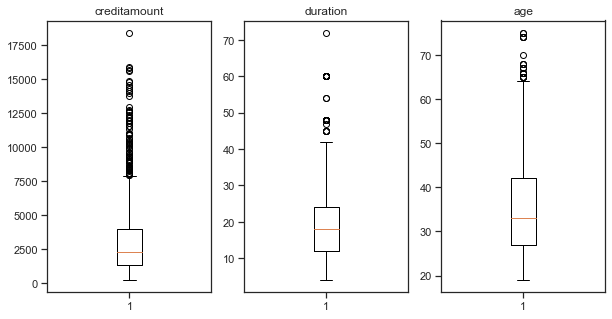

In [9]:
# Boxplots for continuous attributes
# nrows*ncols

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(10,5))
axes[0].boxplot(credit_card['creditamount'].dropna())
axes[0].set_title('creditamount')
axes[1].boxplot(credit_card['duration'].dropna())
axes[1].set_title('duration')
axes[2].boxplot(credit_card['age'].dropna())
axes[2].set_title('age')

fig.savefig("boxplots.png")

In [10]:
#Binaries the y output for easier use of e.g ROC curves -> 0 ='Good' credit
credit_card["Defaulter_NonDefaulter"].replace([1,2],[0,1],inplace=True)
#Print number of 'good' credits (should be 700) and 'bad' credits (should be 300)
credit_card["Defaulter_NonDefaulter"].value_counts()

0    700
1    300
Name: Defaulter_NonDefaulter, dtype: int64

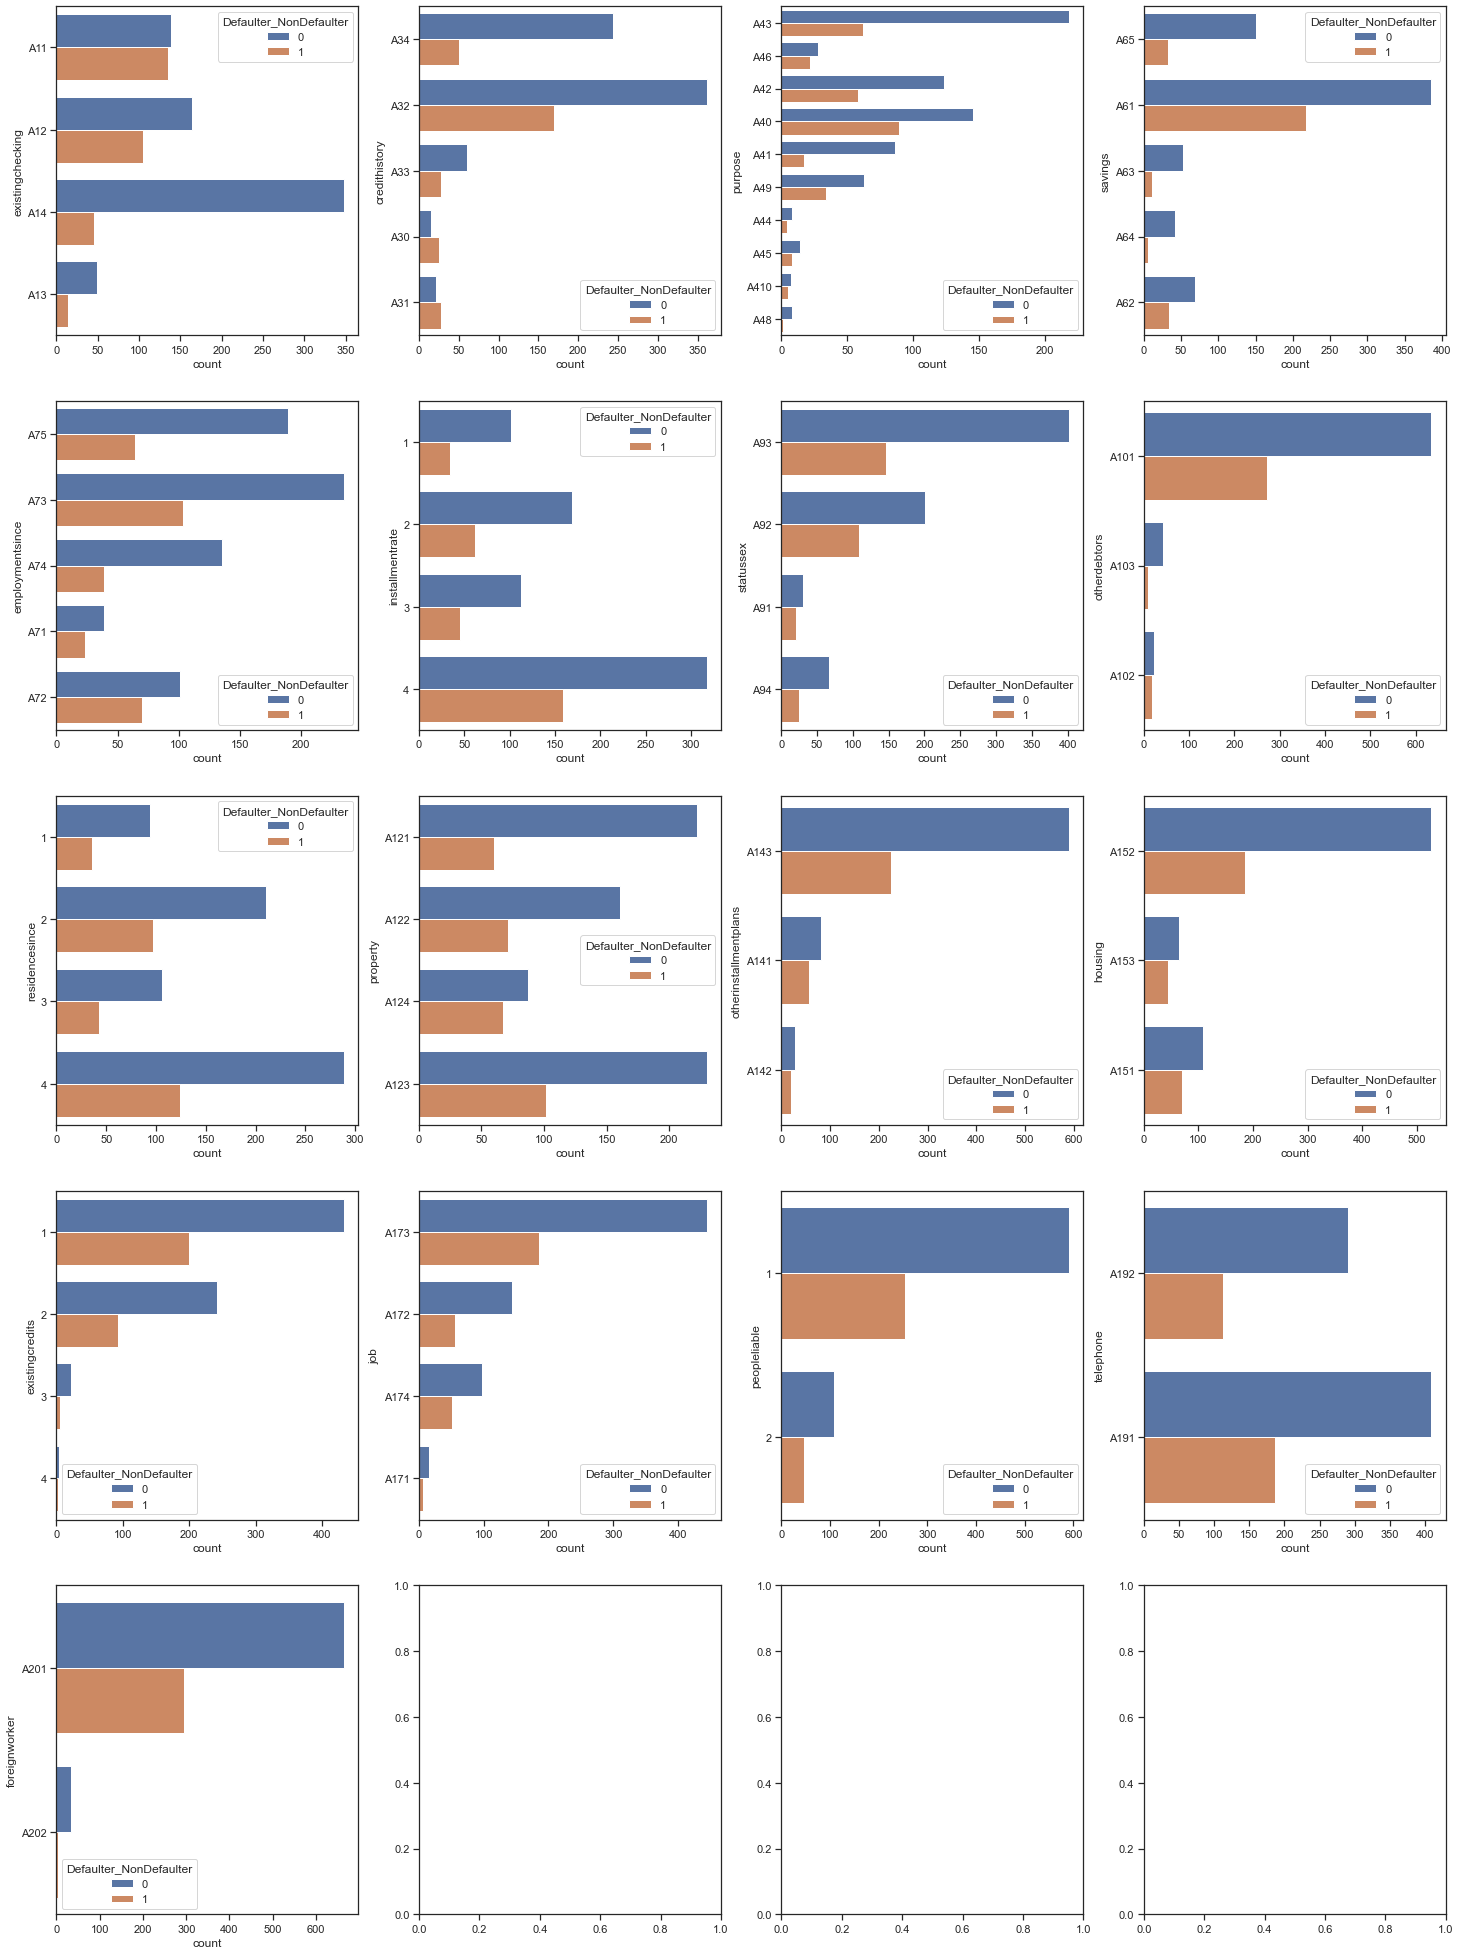

In [11]:
# Barplots for non-continuous attributes

f, axes = plt.subplots(5,4,figsize=(8.3*3,11.7*3))
x=0
y=0
for column in credit_card.drop(['Defaulter_NonDefaulter',
                                'creditamount','duration','age'],axis=1):
    sns.countplot(y=column, hue="Defaulter_NonDefaulter",
                 
                 data=credit_card.drop(['creditamount','duration','age'],axis=1), ax=axes[x,y])
    y+=1
    if y>3:
        x+=1
        y=0
    if x>4:
        break
f.savefig("./barplot.png")

In [12]:
# create quick access list with categorical variables labels
catvars = ['existingchecking','credithistory','purpose','savings','employmentsince','statussex'
          ,'otherdebtors','property','otherinstallmentplans','housing','job','telephone','foreignworker']

# create quick access list with numerical variables labels
numvars = ['creditamount', 'duration','installmentrate','residencesince','age','existingcredits','peopleliable']

In [13]:
credit_card[numvars].nunique()

creditamount       919
duration            33
installmentrate      4
residencesince       4
age                 53
existingcredits      4
peopleliable         2
dtype: int64

In [17]:
# Data Transformation
# Segregating the data into independent and dependent variables

x = credit_card.drop(["Defaulter_NonDefaulter"],axis=1)
y = credit_card["Defaulter_NonDefaulter"]

In [ ]:
# How to handle categorical variables

from IPython.display import Image
Image("../one_hot_encoding.png")

In [19]:
# One Hot Encoding
# Create dummy variables for every category of every categorical variable
x_dumm = pd.get_dummies(x,columns=catvars,drop_first=True)

In [20]:
x_dumm.columns.to_list()

['duration',
 'creditamount',
 'installmentrate',
 'residencesince',
 'age',
 'existingcredits',
 'peopleliable',
 'existingchecking_A12',
 'existingchecking_A13',
 'existingchecking_A14',
 'credithistory_A31',
 'credithistory_A32',
 'credithistory_A33',
 'credithistory_A34',
 'purpose_A41',
 'purpose_A410',
 'purpose_A42',
 'purpose_A43',
 'purpose_A44',
 'purpose_A45',
 'purpose_A46',
 'purpose_A48',
 'purpose_A49',
 'savings_A62',
 'savings_A63',
 'savings_A64',
 'savings_A65',
 'employmentsince_A72',
 'employmentsince_A73',
 'employmentsince_A74',
 'employmentsince_A75',
 'statussex_A92',
 'statussex_A93',
 'statussex_A94',
 'otherdebtors_A102',
 'otherdebtors_A103',
 'property_A122',
 'property_A123',
 'property_A124',
 'otherinstallmentplans_A142',
 'otherinstallmentplans_A143',
 'housing_A152',
 'housing_A153',
 'job_A172',
 'job_A173',
 'job_A174',
 'telephone_A192',
 'foreignworker_A202']

In [21]:
x_dumm.head()

,duration,creditamount,installmentrate,residencesince,age,existingcredits,peopleliable,existingchecking_A12,existingchecking_A13,existingchecking_A14,...,property_A124,otherinstallmentplans_A142,otherinstallmentplans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreignworker_A202
0,6,1169.0,4,4,67.0,2,1,0,0,0,...,0,0,1,1,0,0,1,0,1,0
1,48,5951.0,2,2,22.0,1,1,1,0,0,...,0,0,1,1,0,0,1,0,0,0
2,12,2096.0,2,3,49.0,1,2,0,0,1,...,0,0,1,1,0,1,0,0,0,0
3,42,7882.0,2,4,45.0,1,2,0,0,0,...,0,0,1,0,1,0,1,0,0,0
4,24,4870.0,3,4,53.0,2,2,0,0,0,...,1,0,1,0,1,0,1,0,0,0


In [22]:
x_dumm.shape

(1000, 48)

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x_dumm,y,test_size=0.2)

In [38]:
x_train.shape

(800, 48)

In [39]:
x_test.isnull().sum()

duration                      0
creditamount                  0
installmentrate               0
residencesince                0
age                           0
existingcredits               0
peopleliable                  0
existingchecking_A12          0
existingchecking_A13          0
existingchecking_A14          0
credithistory_A31             0
credithistory_A32             0
credithistory_A33             0
credithistory_A34             0
purpose_A41                   0
purpose_A410                  0
purpose_A42                   0
purpose_A43                   0
purpose_A44                   0
purpose_A45                   0
purpose_A46                   0
purpose_A48                   0
purpose_A49                   0
savings_A62                   0
savings_A63                   0
savings_A64                   0
savings_A65                   0
employmentsince_A72           0
employmentsince_A73           0
employmentsince_A74           0
employmentsince_A75           0
statusse

In [40]:
# Missing value imputation
missing_val_imput(x_train,"age"),missing_val_imput(x_train,"creditamount")

Missing value imputation for age done
Missing value imputation for creditamount done


C:\Users\Rodster\anaconda3\lib\site-packages\pandas\core\indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


(None, None)

In [41]:
# How to handle numerical variable
# Standardization

scaler = StandardScaler()

x_train_standardized = scaler.fit_transform(x_train[numvars])
x_test_standardized = scaler.transform(x_test[numvars])

x_train_standardized = pd.DataFrame(x_train_standardized)
x_test_standardized = pd.DataFrame(x_test_standardized)

print("Standardization done")

Standardization done


In [29]:
x_train_standardized.shape

(800, 48)

In [ ]:
x_train_standardized.columns = numvars
x_test_standardized.columns = numvars

In [42]:
x_train_standardized.head()

,0,1,2,3,4,5,6
0,-0.040171,0.259675,0.042956,-0.769413,-0.412517,0.985887,-0.428290
1,-0.126217,-0.888061,-1.765726,1.062522,-0.412517,-0.713918,-0.428290
2,0.135055,-0.724098,-1.765726,0.146555,-0.412517,-0.713918,2.334869
3,-0.904807,-1.215985,0.042956,1.062522,0.287777,0.985887,-0.428290
4,-0.658166,-1.215985,-1.765726,-0.769413,0.025167,-0.713918,-0.428290


In [44]:
x_train_cat = x_train.drop(numvars,axis=1)
x_test_cat = x_test.drop(numvars,axis=1)

x_train_cat.reset_index(inplace=True,drop=True)
x_test_cat.reset_index(inplace=True,drop=True)

In [45]:
x_train_cat.shape

(800, 41)

In [46]:
y_train.reset_index(inplace=True,drop=True)
y_test.reset_index(inplace=True,drop=True)

In [47]:
y_train.shape

(800,)

In [53]:
# Concating the transformed variables

x_train_transformed = pd.concat([x_train_standardized,x_train_cat],axis=1)

x_test_transformed = pd.concat([x_test_standardized,x_test_cat],axis=1)

print(x_train_transformed.shape)
print(x_test_transformed.shape)

(800, 48)
(200, 48)


In [54]:
x_train_transformed.isnull().sum()

0                             0
1                             0
2                             0
3                             0
4                             0
5                             0
6                             0
existingchecking_A12          0
existingchecking_A13          0
existingchecking_A14          0
credithistory_A31             0
credithistory_A32             0
credithistory_A33             0
credithistory_A34             0
purpose_A41                   0
purpose_A410                  0
purpose_A42                   0
purpose_A43                   0
purpose_A44                   0
purpose_A45                   0
purpose_A46                   0
purpose_A48                   0
purpose_A49                   0
savings_A62                   0
savings_A63                   0
savings_A64                   0
savings_A65                   0
employmentsince_A72           0
employmentsince_A73           0
employmentsince_A74           0
employmentsince_A75           0
statusse

In [57]:
# Oversampling
# Apply SMOTE
sm = SMOTE(k_neighbors=5,sampling_strategy=0.7)
x_train_transformed_smot,y_train_smot = sm.fit_sample(x_train_transformed,y_train)

In [58]:
x_train_transformed_smot.head()

,0,1,2,3,4,5,6,existingchecking_A12,existingchecking_A13,existingchecking_A14,...,property_A124,otherinstallmentplans_A142,otherinstallmentplans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreignworker_A202
0,-0.040171,0.259675,0.042956,-0.769413,-0.412517,0.985887,-0.428290,0,1,0,...,0,0,1,1,0,0,1,0,1,0
1,-0.126217,-0.888061,-1.765726,1.062522,-0.412517,-0.713918,-0.428290,0,0,1,...,0,0,1,0,0,0,1,0,0,0
2,0.135055,-0.724098,-1.765726,0.146555,-0.412517,-0.713918,2.334869,0,0,0,...,0,0,1,1,0,0,1,0,0,0
3,-0.904807,-1.215985,0.042956,1.062522,0.287777,0.985887,-0.428290,0,0,0,...,0,0,1,1,0,1,0,0,1,0
4,-0.658166,-1.215985,-1.765726,-0.769413,0.025167,-0.713918,-0.428290,0,0,0,...,0,0,0,1,0,1,0,0,1,0


In [59]:
type(x_train_transformed_smot)

pandas.core.frame.DataFrame

In [69]:
y_train

0      0
1      0
2      0
3      0
4      0
      ..
795    1
796    0
797    0
798    1
799    0
Name: Defaulter_NonDefaulter, Length: 800, dtype: int64

In [62]:
x_train_transformed_smot.columns = x_train_transformed.columns

In [ ]:
x_train_smot = pd.Series(x_train_smot)

In [ ]:
x_train_smot.value_counts()

In [ ]:
# Function for evaluation reports
def get_eval(clf,x_train,y_train,y_test,y_pred):
    # Cross Validation to test and anticipate overfitting problem
    scores1 = cross_val_score(clf,x_train,t_train,cv=10,scoring="accuracy")
    scores2 = cross_val_score(clf,x_train,t_train,cv=10,scoring="precision")
    scores3 = cross_val_score(clf,x_train,t_train,cv=10,scoring="roc_auc")
# Mean score and standard deviation of the score estimate
    print("Cross Validation Accuracy: %0.2f (+/- %0.2f)" % (scores1.mean(),scores1.std()))
    print("Cross Validation Accuracy: %0.2f (+/- %0.2f)" % (scores2.mean(),scores2.std()))
    print("Cross Validation Accuracy: %0.2f (+/- %0.2f)" % (scores3.mean(),scores3.std()))
# Create and print confusion matrix
    abclf_cm = confusion_matrix(y_test,y_pred)
    print(abclf_cm)
    return

In [ ]:
# Function to get roc curve
def get_roc (y_test,y_pred):
# Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    fpr, tpr, _ = roc_curve(y_test,y_pred)
    roc_auc = auc(fpr,tpr)
# Plot of a ROC curve
    plt.figure()
    lw=2
    plt.plot(fpr,tpr,colr='darkorange',
            label="ROC curve (area = %0.2f)" % roc_auc)
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle="--")
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver operating characteristic")
    plt.legend(loc="lower right")
    plt.show()
    return

In [ ]:
import sklearn
sklearn._version_

In [ ]:
# Decision Tree Classifier
# fit, train and cross validate Decision Tree with training and test data
def dectreeclf(x_train,y_train,x_test,y_test):
    start = time.time()
    print("DecisionTreeClassifier")
    dec_tree = tree.DecisionTreeClassifier(min_samples_split=10,min_samples_leaf)
    
    # Predict target variables y for test data
    y_pred = dec_tree.predict(x_test)
    
    # Export visualization as file
    # visualize_tree(dec_tree,x_train,y_train)
    
    # Get cross validation and confusion matrix
    get_eval(dec_tree,x_train,y_train,y_test,y_pred)
    
    end=time.time()
    training_time = end-start
    print("Time taken: ",training_time)
    return
# Visualize tree and save as .pdf
# Only works for dataframes, not for numpy arrays

In [63]:
# Random Forest Classifier
# fit, train and cross validate Decision Tree with training and test data
def randomforestclf(x_train,y_train,x_test,y_test):
    print("RandomForestClassifier")
    randomforest = RandomForestClassifier().fit(x_train,y_train)
    
# Predict target variables y for test data
    y_pred = randomforest.predict(x_test)
    
# Get Cross Validation and Confusion matrix
    get_eval(random_forest,x_train,y_train,y_test,y_pred)
    return

In [64]:
?RandomForestClassifier

In [ ]:
# Logistic Regression

def logregclf(x_train,y_train,x_test,y_test):
    print("LogisticRegression")
    logreg = LogisticRegression().fit(x_train,y_train)
    
# Predict target variables y for test data
    y_pred = logreg.predict(x_test)
    
# Get Cross Validation and Confusion matrix
    get_eval(logreg,x_train,y_train,y_test,y_pred)
    return

In [ ]:
# K Neighbors Classifier

def knnclf(x_train,y_train,x_test,y_test):
    print("KNeighborsClassifier")
    logreg = KNeighborsClassifier(n_neighbors=3).fit(x_train,y_train)
    
# Predict target variables y for test data
    y_pred = knn.predict(x_test)
    
# Get Cross Validation and Confusion matrix
    get_eval(knn,x_train,y_train,y_test,y_pred)
    return

In [ ]:
x_test_transformed.isnull().sum()

In [ ]:
x_test_transformed.loc[x_test_transformed["creditamount"].isnull(),"creditamount"] = x_train_transformed["creditamount"].median()
x_test_transformed.loc[x_test_transformed["age"].isnull(),"age"] = x_train_transformed["age"].median()

In [ ]:
y_train_smot.value_counts(dropna=False)
y_test_smot.value_counts(dropna=False)

In [ ]:
# Decision Trees
# train, test and evaluate the classifiers with different preprocessed data
print("clean resampled")
dectreeclf(x_train_transformed_smot,y_train_smot,x_test_transformed,y_test)

In [ ]:
# Decision Trees

print("clean resampled")
randomforestclf(x_train_transformed_smot,y_train_smot,x_test_transformed,y_test)

In [ ]:
# Logistic Regression

print("clean resampled")
logregclf(x_train_transformed_smot,y_train_smot,x_test_transformed,y_test)

In [ ]:
# KNN Classifier

print("clean resampled")
knnclf(x_train_transformed_smot,y_train_smot,x_test_transformed,y_test)

In [71]:
# Recursive feature elimination (RFE)
# Use clean data, as Logistic Regression should be robust do different feature
rfe = RFE(LogisticRegression(),15)
fit = rfe.fit(x_train_transformed_smot,y_train_smot)
print("Num features: %d" % fit.n_features_)
print("Selected Features: %s" % fit.support_)
print("Feature Ranking: %s" % fit.ranking_)

C:\Users\Rodster\anaconda3\lib\site-packages\sklearn\utils\validation.py:68: FutureWarning: Pass n_features_to_select=15 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  warnings.warn("Pass {} as keyword args. From version 0.25 "


Num features: 15
Selected Features: [False False False False False False False False  True  True False  True
  True  True  True False False False False False False  True False False
  True  True  True False False False False False False False False  True
 False False False False False False False  True  True  True False  True]
Feature Ranking: [13 22 17 34 28 30 33 11  1  1 18  1  1  1  1 26  8  7  6 16 29  1  9 21
  1  1  1 25 20  5 19  4  3  2 27  1 31 32 23 24 10 14 15  1  1  1 12  1]


In [73]:
# Apply fitted transformation to datasets

RFEx_train = rfe.transform(x_train_transformed_smot)
RFEx_test = rfe.transform(x_test_transformed)
RFEy_train = y_train_smot
RFEy_test = y_test

In [74]:
RFEx_train[0]

array([1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.])

In [81]:
imp_cols = fit.ranking_

In [82]:
imp_cols

array([13, 22, 17, 34, 28, 30, 33, 11,  1,  1, 18,  1,  1,  1,  1, 26,  8,
        7,  6, 16, 29,  1,  9, 21,  1,  1,  1, 25, 20,  5, 19,  4,  3,  2,
       27,  1, 31, 32, 23, 24, 10, 14, 15,  1,  1,  1, 12,  1])

In [77]:
imp_cols = list(imp_cols)

In [79]:
imp_var_ind = []
for i in range(len(imp_cols)):
    if imp_cols[i] ==   1:
        imp_var_ind.append(i)

In [80]:
imp_var_ind

[8, 9, 11, 12, 13, 14, 21, 24, 25, 26, 35, 43, 44, 45, 47]

In [ ]:
var_list = x_train_transformed_smot.columns.to_list()

In [ ]:
var_name = []
for i in imp_var_ind:
    var_name.append(var_list[i])
    
var_name